<a href="https://colab.research.google.com/github/Ahmedkhairy-tech/Sales-Data-Analysis-Project-by-paython-/blob/main/360%C2%B0_Marketing_Performance_Insights.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_excel('/content/01KA3A8HS7A4A8R7NETRZA2W8J.xlsx')

In [4]:
df.shape

(2000, 7)

In [5]:
df.columns

Index(['Date', 'Channel', 'Service Category', 'Ad Spend', 'Conversions',
       'Revenue', 'Customer Type'],
      dtype='object')

In [6]:
df.sample(6)

,Date,Channel,Service Category,Ad Spend,Conversions,Revenue,Customer Type
894,2024-02-16,Instagram,Basic,43.68,7,101.01,New
888,2024-02-15,Instagram,Deluxe,6.92,4,18.64,New
590,2024-03-05,Referral,Basic,8.45,0,10.90,New
5,2024-03-13,Flyer,Premium,57.77,3,134.72,New
1440,2024-02-01,Instagram,Basic,96.44,9,206.21,Returning
1075,2024-04-08,Instagram,Premium,54.43,9,188.33,New


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Date              2000 non-null   datetime64[ns]
 1   Channel           2000 non-null   object        
 2   Service Category  2000 non-null   object        
 3   Ad Spend          2000 non-null   float64       
 4   Conversions       2000 non-null   int64         
 5   Revenue           2000 non-null   float64       
 6   Customer Type     2000 non-null   object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(3)
memory usage: 109.5+ KB


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.isna().sum()

,0
Date,0
Channel,0
Service Category,0
Ad Spend,0
Conversions,0
Revenue,0
Customer Type,0


**أي قناة إعلانية تحقق أعلى إيرادات؟**

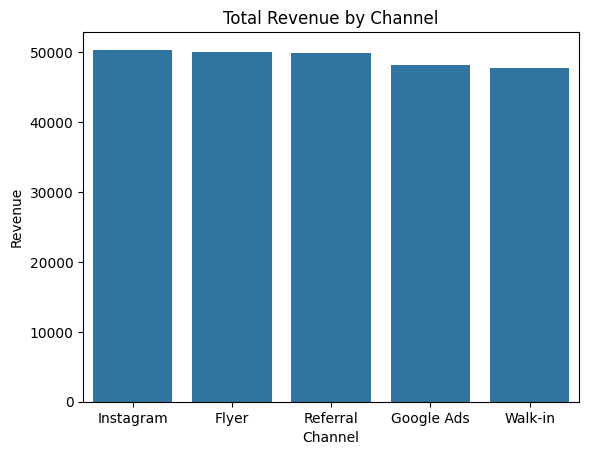

In [16]:

channel_revenue = df.groupby('Channel')['Revenue'].sum().sort_values(ascending=False).reset_index()

sns.barplot(data=channel_revenue, x='Channel', y='Revenue')
plt.title("Total Revenue by Channel")
plt.ylabel("Revenue")
plt.show()


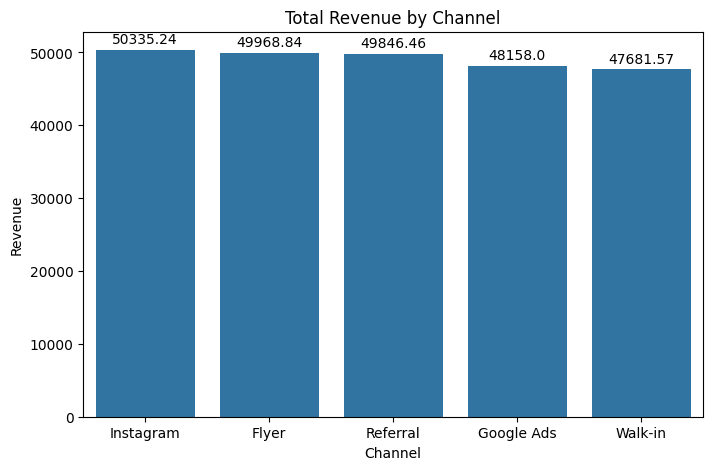

In [15]:

channel_revenue = df.groupby('Channel')['Revenue'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=channel_revenue, x='Channel', y='Revenue')
for index, row in channel_revenue.iterrows():
    plt.text(index, row['Revenue'] + row['Revenue']*0.01, round(row['Revenue'],2), ha='center', va='bottom')

plt.title("Total Revenue by Channel")
plt.ylabel("Revenue")
plt.show()


**أي نوع من العملاء يحقق أكبر عدد من التحويلات؟**

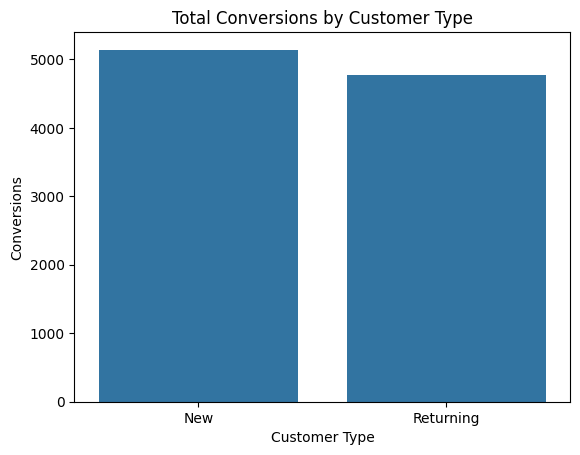

In [17]:
customer_conversions = df.groupby('Customer Type')['Conversions'].sum().sort_values(ascending=False).reset_index()

sns.barplot(data=customer_conversions, x='Customer Type', y='Conversions')
plt.title("Total Conversions by Customer Type")
plt.show()


**هل هناك علاقة بين الإنفاق والإيرادات؟**

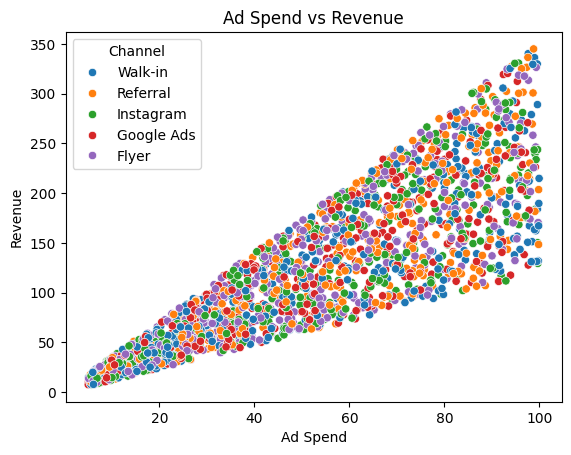

In [18]:
sns.scatterplot(data=df, x='Ad Spend', y='Revenue', hue='Channel')
plt.title("Ad Spend vs Revenue")
plt.show()


**أي فئة خدمة تحقق أعلى إيرادات؟**

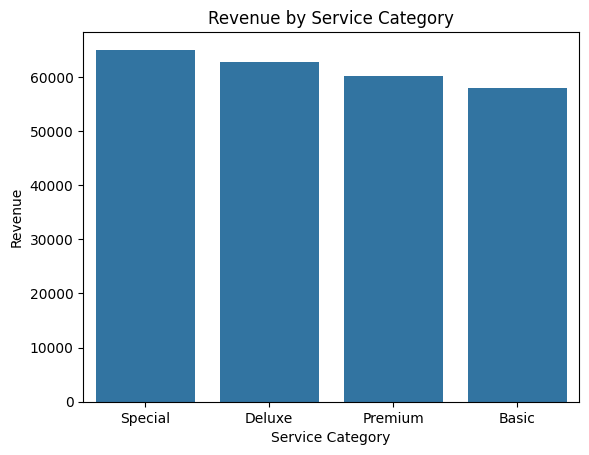

In [20]:
service_revenue = df.groupby('Service Category')['Revenue'].sum().sort_values(ascending=False).reset_index()

sns.barplot(data=service_revenue, x='Service Category', y='Revenue')
plt.title("Revenue by Service Category")
plt.show()


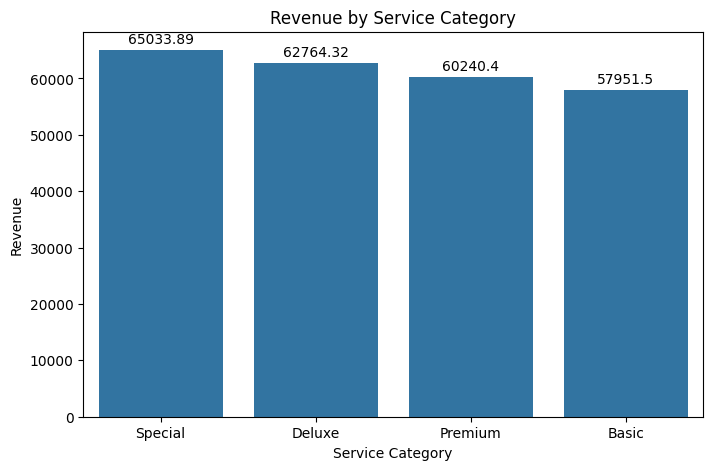

In [21]:

service_revenue = df.groupby('Service Category')['Revenue'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=service_revenue, x='Service Category', y='Revenue')

for index, row in service_revenue.iterrows():
    plt.text(index, row['Revenue'] + row['Revenue']*0.01, round(row['Revenue'],2), ha='center', va='bottom')

plt.title("Revenue by Service Category")
plt.ylabel("Revenue")
plt.show()


**كيف يتغير الإيراد شهريًا؟**

In [23]:
df['Month'] = df['Date'].dt.month


In [24]:
df['Day'] = df['Date'].dt.day

In [25]:
df['Year'] = df['Date'].dt.year

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Date              2000 non-null   datetime64[ns]
 1   Channel           2000 non-null   object        
 2   Service Category  2000 non-null   object        
 3   Ad Spend          2000 non-null   float64       
 4   Conversions       2000 non-null   int64         
 5   Revenue           2000 non-null   float64       
 6   Customer Type     2000 non-null   object        
 7   Month             2000 non-null   int32         
 8   Day               2000 non-null   int32         
 9   Year              2000 non-null   int32         
dtypes: datetime64[ns](1), float64(2), int32(3), int64(1), object(3)
memory usage: 132.9+ KB


/tmp/ipython-input-1122559793.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=monthly_revenue, x='Month', y='Revenue', palette='viridis')


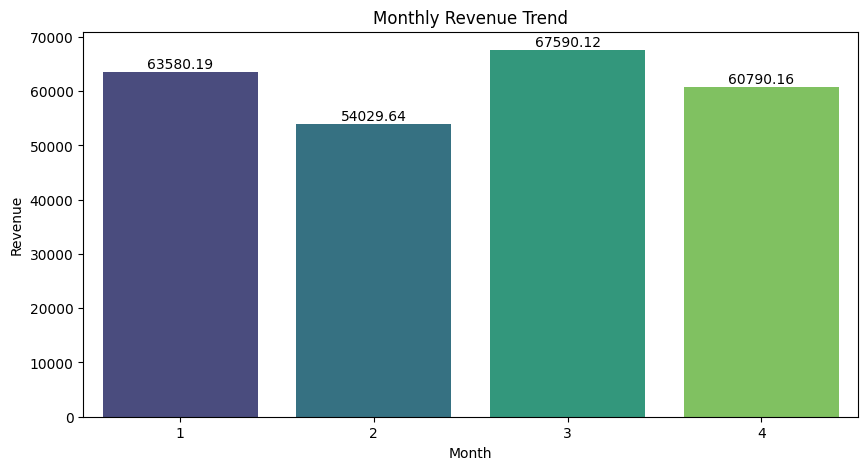

In [35]:
monthly_revenue = df.groupby('Month')['Revenue'].sum().reset_index()

plt.figure(figsize=(10,5))
sns.barplot(data=monthly_revenue, x='Month', y='Revenue', palette='viridis')

for i, row in monthly_revenue.iterrows():
    plt.text(i, row['Revenue'] + row['Revenue']*0.01, round(row['Revenue'],2), ha='center')

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()


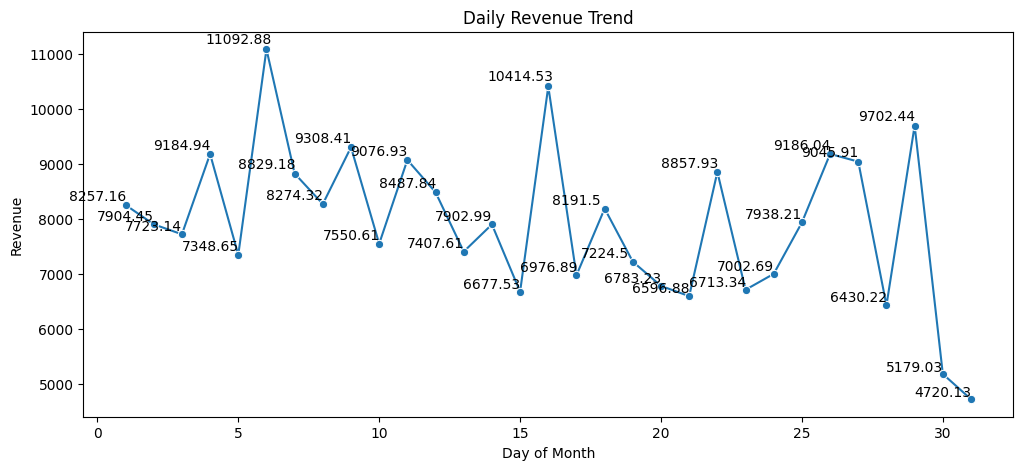

In [28]:
daily_revenue = df.groupby('Day')['Revenue'].sum().reset_index()

plt.figure(figsize=(12,5))
sns.lineplot(data=daily_revenue, x='Day', y='Revenue', marker='o')

for i, row in daily_revenue.iterrows():
    plt.text(i, row['Revenue'] + row['Revenue']*0.01, round(row['Revenue'],2), ha='center')

plt.title("Daily Revenue Trend")
plt.xlabel("Day of Month")
plt.ylabel("Revenue")
plt.show()


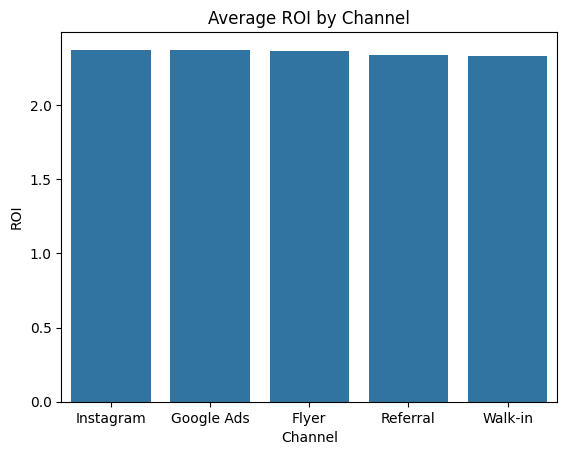

In [30]:
df['ROI'] = df['Revenue'] / df['Ad Spend']
roi_channel = df.groupby('Channel')['ROI'].mean().sort_values(ascending=False).reset_index()

sns.barplot(data=roi_channel, x='Channel', y='ROI')
plt.title("Average ROI by Channel")
plt.show()


/tmp/ipython-input-1706210399.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=roi_channel, x='Channel', y='ROI', palette='viridis')


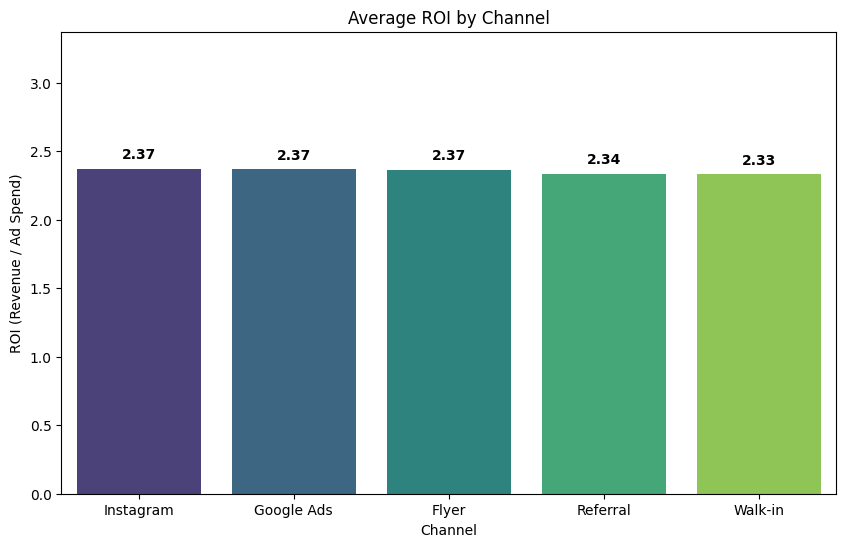

In [31]:

df['ROI'] = df['Revenue'] / df['Ad Spend']

roi_channel = df.groupby('Channel')['ROI'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10,6))
sns.barplot(data=roi_channel, x='Channel', y='ROI', palette='viridis')

for i, row in roi_channel.iterrows():
    plt.text(i, row['ROI'] + 0.05, f"{row['ROI']:.2f}", ha='center', va='bottom', fontweight='bold')
plt.title("Average ROI by Channel")
plt.ylabel("ROI (Revenue / Ad Spend)")
plt.xlabel("Channel")
plt.ylim(0, roi_channel['ROI'].max() + 1)
plt.show()


In [34]:
df.to_csv('udemy_courses_cleanbypaython.csv',index=False)
from google.colab import files
files.download('udemy_courses_cleanbypaython.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>